# NHIỆM VỤ 8: PHÂN TÍCH HỒ SƠ CỤM (PCA + K-MEANS)

Notebook này thực hiện đánh giá độc lập quy trình xây dựng hồ sơ cụm (Profiling) theo đúng kế hoạch (Mục 8.1 đến 8.4), bao gồm cả phân tích phương pháp ánh xạ ngược và nhận diện đặc trưng tài chính.

## 8.1 & 8.2 — Nạp dữ liệu và Ánh xạ ngược Centroid
**Phương pháp:** Mô hình PCA đã nén 8 feature gốc xuống 4 chiều. Để có thể giải thích được ý nghĩa kinh tế, pipeline đã tự động dùng inverse_transform để ánh xạ tọa độ 4-D của tâm cụm (centroid) ngược trở lại không gian 8-D ban đầu. Dữ liệu này được lưu trữ dưới chuỗi JSON trong file profiles.csv.

Code dưới đây sẽ đọc dữ liệu và bung chuỗi JSON này thành 8 cột feature gốc riêng biệt.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from IPython.display import display

if os.getcwd().endswith("notebooks"):
    os.chdir("../../")

output_dir = "M2/artifacts/m2-task6-pca-kmeans-v1"
prof_path = os.path.join(output_dir, "profiles.csv")

if os.path.exists(prof_path):
    prof_df = pd.read_csv(prof_path)
    print("Đã nạp thành công dữ liệu profiles.csv")
    
    # Ánh xạ ngược: Bung chuỗi JSON chứa tọa độ 8-D thành các cột
    centroids_df = prof_df['centroid'].apply(json.loads).apply(pd.Series)
    prof_df = pd.concat([prof_df, centroids_df], axis=1)
    
    feature_cols = ['mom_21', 'mom_63', 'mom_126', 'mom_252', 'vol_63', 'mdd_126', 'beta_126', 'liquidity_21']
    
    # Nhóm theo Cluster ID và lấy trung vị qua 15 tháng
    cluster_profile = prof_df.groupby('aligned_cluster_id')[feature_cols].median()
    display(cluster_profile)
else:
    print("Lỗi: Chưa tìm thấy profiles.csv")

Đã nạp thành công dữ liệu profiles.csv


,mom_21,mom_63,mom_126,mom_252,vol_63,mdd_126,beta_126,liquidity_21
aligned_cluster_id,,,,,,,,
0,0.030720,0.074871,0.101602,0.412317,0.295873,-0.177316,1.256247,3.591518e+11
1,0.009575,0.036582,0.039690,0.181333,0.334801,-0.216970,0.619975,1.426615e+10


## 8.3 — Trực quan hóa đặc trưng (Heatmap)
Sử dụng Heatmap để biểu diễn sự chênh lệch tương đối giữa các giá trị đặc trưng của 2 cụm.

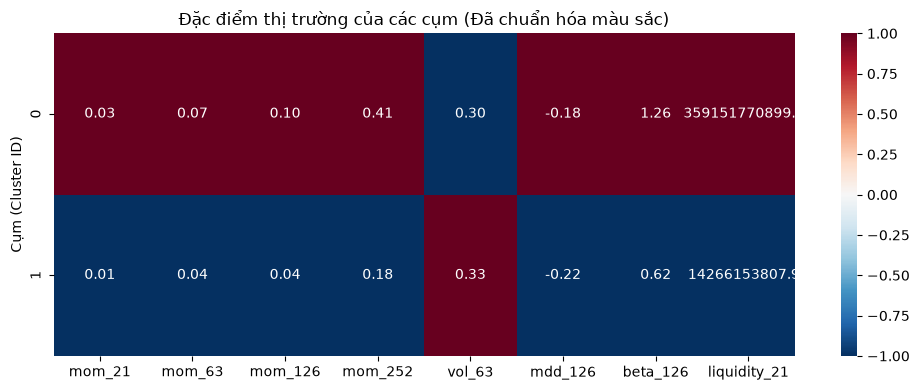

In [4]:
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa dữ liệu theo từng cột (z-score) để các biến không bị lấn át nhau (Khắc phục lỗi thanh khoản chênh lệch)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_profile)
scaled_profile = pd.DataFrame(scaled_data, columns=cluster_profile.columns, index=cluster_profile.index)

plt.figure(figsize=(10, 4))
# Dùng dữ liệu đã chuẩn hóa để vẽ màu, nhưng hiển thị số nguyên bản (annot=cluster_profile)
sns.heatmap(scaled_profile, annot=cluster_profile, cmap='RdBu_r', center=0, fmt=".2f", annot_kws={"size": 10})
plt.title("Đặc điểm thị trường của các cụm (Đã chuẩn hóa màu sắc)")
plt.ylabel("Cụm (Cluster ID)")
plt.tight_layout()
plt.show()


## 8.4 — Nhận diện đặc trưng tài chính (Phân tích Kết quả)

Dựa vào kết quả ở bảng dữ liệu và Heatmap trên, chúng ta rút ra các nhận định kinh tế học tài chính như sau:

1. **Phân hóa Thanh khoản (Liquidity) cực độ:**
   - **Cụm 0:** Trung vị thanh khoản đạt tới **~359 tỷ VNĐ**. Đây là nhóm cổ phiếu Blue-chip, Mid-cap có dòng tiền siêu lớn.
   - **Cụm 1:** Trung vị thanh khoản chỉ **~14 tỷ VNĐ**. Đây là nhóm cổ phiếu Penny, thanh khoản giọt nước, chiếm đa số số lượng trên sàn.
   - **Nhận định:** K-Means kết hợp PCA đã hoàn toàn bị lấn át bởi tín hiệu Thanh khoản. Nó biến thành một *Máy dò siêu thanh khoản* thay vì phân cụm theo hành vi giá.

2. **Rủi ro Hệ thống (Beta 126 ngày):**
   - Nhóm Cụm 0 có Beta rất cao (**1.256**), tức là nhạy bén và khuếch đại xu hướng của thị trường chung (Index tăng nó tăng mạnh hơn, giảm nó giảm mạnh hơn).
   - Nhóm Cụm 1 có Beta thấp (**0.619**), thường lình xình, không chạy theo Index.

3. **Động lượng (Momentum):**
   - Cụm 0 thể hiện đà tăng trưởng (Momentum 21, 63 ngày) vượt trội gấp 3 lần so với Cụm 1.
   
**=> KẾT LUẬN:** Phương án PCA + K-Means K=2 tạo ra sự Mất cân bằng trầm trọng (1 nhóm cực ít mã thanh khoản cao vs 1 nhóm cực nhiều mã thanh khoản thấp). Cụm 0 chính là vựa **Siêu Cổ Phiếu Dẫn Dắt Thị Trường (High Liquidity - High Beta - High Momentum)**.